<a href="https://colab.research.google.com/github/MouseLand/cellpose/blob/main/notebooks/train_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook shows how to train Cellpose SAM with 3D NeuroPAL images.


### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

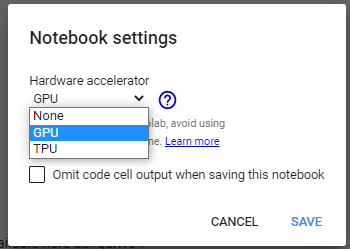

### Install Cellpose-SAM


In [ ]:
!pip install git+https://www.github.com/mouseland/cellpose.git

Check GPU and instantiate model - will download weights.

In [1]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

2026-04-21 04:59:13,162 [INFO] WRITING LOG OUTPUT TO /home/anshitagupta_umass_edu/.cellpose/run.log
2026-04-21 04:59:13,162 [INFO] 
cellpose version: 	4.0.10.dev21+g849ca11f1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-04-21 04:59:13,419 [INFO] ** TORCH CUDA version installed and working. **
2026-04-21 04:59:13,420 [INFO] ** TORCH CUDA version installed and working. **
2026-04-21 04:59:13,421 [INFO] >>>> using GPU (CUDA)
2026-04-21 04:59:14,990 [INFO] >>>> loading model /home/anshitagupta_umass_edu/.cellpose/models/cpsam


Input directory with your images (if you have them, otherwise use sample images):

In [2]:
# *** change to your annotation folder path (with images and masks) ***
train_dir = "test_data_clean/train_annotations_000715_sub-11-YAaLR_anisotropic"
if not Path(train_dir).exists():
  raise FileNotFoundError("directory does not exist")

test_dir = None # optionally you can specify a directory with test files (images and masks)

# *** change to your mask extension ***
masks_ext = "_seg.npy"
# ^ assumes images from Cellpose GUI, if labels are tiffs, then "_masks.tif"

# list all files
files = [f for f in Path(train_dir).glob("*") if "_masks" not in f.name and "_flows" not in f.name and "_seg" not in f.name]

if(len(files)==0):
  raise FileNotFoundError("no files found, did you specify the correct folder and extension?")
else:
  print(f"{len(files)} files in folder:")

for f in files:
  print(f.name)

24 files in folder:
000715_sub-11-YAaLR_anisotropic_YX_0.tif
000715_sub-11-YAaLR_anisotropic_YX_1.tif
000715_sub-11-YAaLR_anisotropic_YX_11.tif
000715_sub-11-YAaLR_anisotropic_YX_12.tif
000715_sub-11-YAaLR_anisotropic_YX_16.tif
000715_sub-11-YAaLR_anisotropic_YX_17.tif
000715_sub-11-YAaLR_anisotropic_YX_2.tif
000715_sub-11-YAaLR_anisotropic_YX_8.tif
000715_sub-11-YAaLR_anisotropic_ZX_187.tif
000715_sub-11-YAaLR_anisotropic_ZX_212.tif
000715_sub-11-YAaLR_anisotropic_ZX_240.tif
000715_sub-11-YAaLR_anisotropic_ZX_260.tif
000715_sub-11-YAaLR_anisotropic_ZX_3.tif
000715_sub-11-YAaLR_anisotropic_ZX_354.tif
000715_sub-11-YAaLR_anisotropic_ZX_412.tif
000715_sub-11-YAaLR_anisotropic_ZX_48.tif
000715_sub-11-YAaLR_anisotropic_ZY_122.tif
000715_sub-11-YAaLR_anisotropic_ZY_123.tif
000715_sub-11-YAaLR_anisotropic_ZY_16.tif
000715_sub-11-YAaLR_anisotropic_ZY_41.tif
000715_sub-11-YAaLR_anisotropic_ZY_46.tif
000715_sub-11-YAaLR_anisotropic_ZY_58.tif
000715_sub-11-YAaLR_anisotropic_ZY_66.tif
000715_sub-

## Train new model

In [3]:
from cellpose import train

model_name = "new_model"

# default training params
n_epochs = 100
learning_rate = 1e-5
weight_decay = 0.1
batch_size = 1

# get files
output = io.load_train_test_data(train_dir, test_dir, mask_filter=masks_ext)
train_data, train_labels, _, test_data, test_labels, _ = output
# (not passing test data into function to speed up training)

new_model_path, train_losses, test_losses = train.train_seg(model.net,
                                                            train_data=train_data,
                                                            train_labels=train_labels,
                                                            batch_size=batch_size,
                                                            n_epochs=n_epochs,
                                                            learning_rate=learning_rate,
                                                            weight_decay=weight_decay,
                                                            nimg_per_epoch=max(2, len(train_data)), # can change this
                                                            model_name=model_name)


2026-04-21 04:59:15,584 [INFO] not all flows are present, running flow generation for all images
2026-04-21 04:59:15,665 [INFO] 24 / 24 images in test_data_clean/train_annotations_000715_sub-11-YAaLR_anisotropic folder have labels
2026-04-21 04:59:15,665 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-21 04:59:15,670 [INFO] computing flows for labels


100%|██████████| 24/24 [00:00<00:00, 75.51it/s]

2026-04-21 04:59:15,994 [INFO] >>> computing diameters



100%|██████████| 24/24 [00:00<00:00, 11565.18it/s]

2026-04-21 04:59:15,998 [WARNING] 6 train images with number of masks less than min_train_masks (5), removing from train set
2026-04-21 04:59:15,998 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}
2026-04-21 04:59:16,039 [INFO] >>> n_epochs=100, n_train=18, n_test=None
2026-04-21 04:59:16,039 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.10000
2026-04-21 04:59:16,041 [INFO] >>> saving model to /scratch/workspace/anshitagupta_umass_edu-ai-neuropal/anshita_experiments/cellpose/neuropal/models/new_model


2026-04-21 04:59:35,198 [INFO] 0, train_loss=0.0339, test_loss=0.0000, LR=0.000000, time 19.16s
2026-04-21 05:01:09,154 [INFO] 5, train_loss=0.0385, test_loss=0.0000, LR=0.000006, time 113.11s
2026-04-21 05:02:43,270 [INFO] 10, train_loss=0.0255, test_loss=0.0000, LR=0.000010, time 207.23s
2026-04-21 05:05:51,599 [INFO] 20, train_loss=0.0257, test_loss=0.0000, LR=0.000010, time 395.56s
2026-04-21 05:08:59,934 [INFO] 30, train_loss=0.0238, test_loss=0.0000, LR=0.000010, time 583.89s
2026-04-21 05:12:08,287 [INFO] 40, train_loss=0.0197, test_loss=0.0000, LR=0.000010, time 772.25s
2026-04-21 05:15:16,619 [INFO] 50, train_loss=0.0219, test_loss=0.0000, LR=0.000005, time 960.58s
2026-04-21 05:18:25,044 [INFO] 60, train_loss=0.0203, test_loss=0.0000, LR=0.000001, time 1149.00s
2026-04-21 05:21:33,366 [INFO] 70, train_loss=0.0192, test_loss=0.0000, LR=0.000000, time 1337.33s
2026-04-21 05:24:41,685 [INFO] 80, train_loss=0.0183, test_loss=0.0000, LR=0.000000, time 1525.65s
2026-04-21 05:27:49,

## Evaluate on test data

[000715] sub-56-YAaDV
  Datatype:       float32
  Shape:          (486, 115, 18, 3)
  Min:            0.0, Max: 254.0
  Mean:           2.2472
  Std Dev:        12.0007
  Median:         1.0000
  Size (MB):      12.07 MB
  Num Elements:   3018060
  Ndim:           4


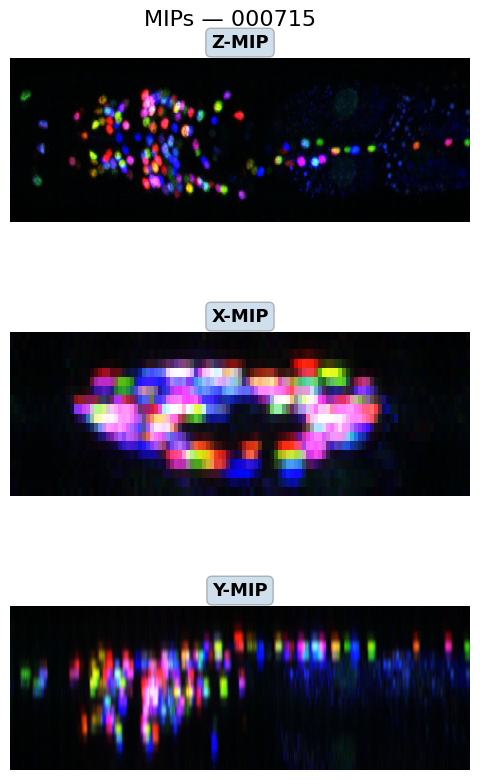

In [ ]:
from ..scripts.utils import load_raw_data, load_clean_data
from ..scripts.utils_graphs import plot_3d_mip

RAW_DATA = False # Can be True or False
dataset = "000715" # Can be 000981 or 000715
csv_col_suffix = "_aniso" # Can be "_aniso" or "_iso"

if RAW_DATA:
    test_data, img_data = load_raw_data(dataset, sample_size=1)
else:
    test_data, img_data = load_clean_data(dataset, csv_col_suffix, sample_size=1)

plt = plot_3d_mip(img_data[0], dataset, figsize=(5, 8))
plt.show()

In [11]:
from cellpose import metrics

model = models.CellposeModel(gpu=True)

# run original model on test images
masks_pretrained, flows, _ = model.eval(
    img_data[0],
    z_axis=2,          
    channel_axis=3,   
    do_3D=True,
    flow3D_smooth=1,
    batch_size=32,
)

# run trained model on test images
model = models.CellposeModel(gpu=True,
                             pretrained_model=new_model_path)

# run model on test images
masks, flows, _ = model.eval(
    img_data[0],
    z_axis=2,          
    channel_axis=3,   
    do_3D=True,
    flow3D_smooth=1,
    batch_size=32,
)

2026-04-21 05:36:31,046 [INFO] ** TORCH CUDA version installed and working. **
2026-04-21 05:36:31,048 [INFO] >>>> using GPU (CUDA)
2026-04-21 05:36:32,444 [INFO] >>>> loading model /home/anshitagupta_umass_edu/.cellpose/models/cpsam
2026-04-21 05:36:32,964 [INFO] running YX: 18 planes of size (486, 115)
2026-04-21 05:36:39,819 [INFO] 100%|##########| 2/2 [00:06<00:00,  3.43s/it]
2026-04-21 05:36:39,823 [INFO] running ZY: 486 planes of size (18, 115)
2026-04-21 05:37:41,929 [INFO] 100%|##########| 16/16 [01:02<00:00,  3.88s/it]
2026-04-21 05:37:41,942 [INFO] running ZX: 115 planes of size (18, 486)
2026-04-21 05:38:26,106 [INFO] 100%|##########| 12/12 [00:44<00:00,  3.68s/it]
2026-04-21 05:38:26,119 [INFO] network run in 113.15s
2026-04-21 05:38:26,125 [INFO] smoothing flows with ZYX sigma=[1, 1, 1]
2026-04-21 05:38:26,501 [INFO] masks created in 0.07s
2026-04-21 05:38:26,523 [INFO] ** TORCH CUDA version installed and working. **
2026-04-21 05:38:26,524 [INFO] >>>> using GPU (CUDA)
202

plot masks

3D Merged Predictions Original Model — X: [179:307], Y: [0:92], Number of segments: 163


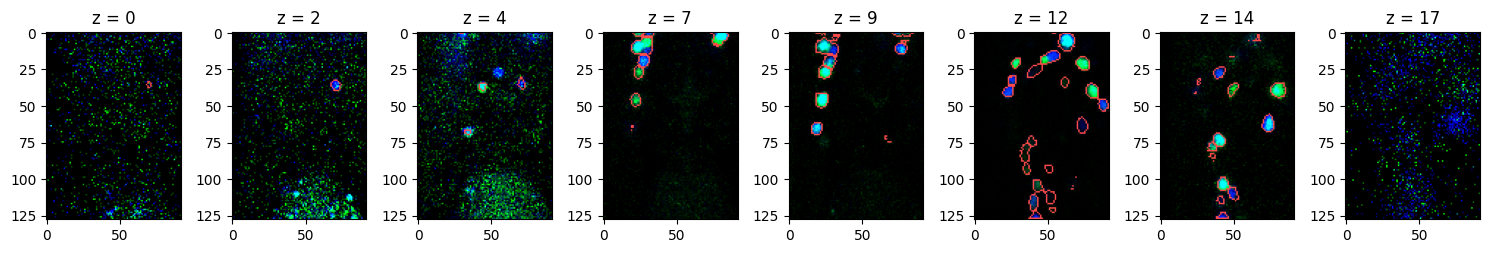

In [38]:
# DISPLAY RESULTS 3D flows => masks
from cellpose import utils

n_z      = masks.shape[0]  # actual Z depth, don't hardcode 75
n_panels = 8
z_planes = np.linspace(0, n_z - 1, n_panels, dtype=int)  # evenly spaced Z slices

# crop image
crop_size = 128

cx = img_data[0].shape[0] // 2   
cy = img_data[0].shape[1] // 4 

x0 = max(0, cx - crop_size // 2)
x1 = min(img_data[0].shape[0], cx + crop_size // 2)
y0 = max(0, cy - crop_size // 2)
y1 = min(img_data[0].shape[1], cy + crop_size // 2)

print(f"3D Merged Predictions Original Model — X: [{x0}:{x1}], Y: [{y0}:{y1}], Number of segments: {masks_pretrained.max()}")

plt.figure(figsize=(15, 3))
for i, iplane in enumerate(z_planes):

    # ── Image slice
    img_slice = img_data[0][x0:x1, y0:y1 , iplane, [1, 0]].transpose(2, 0, 1)   # (2, X, Y)
    img0 = plot.image_to_rgb(img_slice.copy(), channels=[2,3])

    plt.subplot(1, n_panels, i + 1)

    # ── Mask slice
    mask_slice = masks_pretrained[iplane, x0:x1, y0:y1]
    outlines = utils.masks_to_outlines(mask_slice)
    outX, outY = np.nonzero(outlines)
    imgout = img0.copy()
    imgout[outX, outY] = np.array([255, 75, 75])

    plt.imshow(imgout)
    plt.title(f'z = {iplane}')

plt.tight_layout()
plt.show()

3D Merged Predictions Trained Model — X: [179:307], Y: [0:92], Number of segments: 124


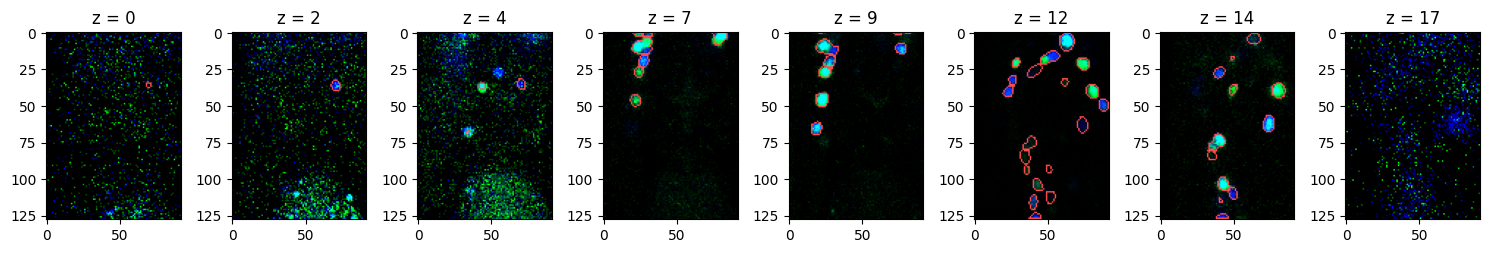

In [37]:
# DISPLAY RESULTS 3D flows => masks
from cellpose import utils

n_z      = masks.shape[0]  # actual Z depth, don't hardcode 75
n_panels = 8
z_planes = np.linspace(0, n_z - 1, n_panels, dtype=int)  # evenly spaced Z slices

# crop image
crop_size = 128

cx = img_data[0].shape[0] // 2   
cy = img_data[0].shape[1] // 4 

x0 = max(0, cx - crop_size // 2)
x1 = min(img_data[0].shape[0], cx + crop_size // 2)
y0 = max(0, cy - crop_size // 2)
y1 = min(img_data[0].shape[1], cy + crop_size // 2)

print(f"3D Merged Predictions Trained Model — X: [{x0}:{x1}], Y: [{y0}:{y1}], Number of segments: {masks.max()}")

plt.figure(figsize=(15, 3))
for i, iplane in enumerate(z_planes):

    # ── Image slice
    img_slice = img_data[0][x0:x1, y0:y1 , iplane, [1, 0]].transpose(2, 0, 1)   # (2, X, Y)
    img0 = plot.image_to_rgb(img_slice.copy(), channels=[2,3])

    plt.subplot(1, n_panels, i + 1)

    # ── Mask slice
    mask_slice = masks[iplane, x0:x1, y0:y1]
    outlines = utils.masks_to_outlines(mask_slice)
    outX, outY = np.nonzero(outlines)
    imgout = img0.copy()
    imgout[outX, outY] = np.array([255, 75, 75])

    plt.imshow(imgout)
    plt.title(f'z = {iplane}')

plt.tight_layout()
plt.show()